In [29]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean
import matplotlib

plt.rcParams['figure.dpi'] = 300
matplotlib.rcParams["font.family"]     = "DejaVu Sans"
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["mathtext.default"] = "regular"      
matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.facecolor"]   = "white"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda:1


load model

In [30]:
from models.unet.default import Unet

N_EULER = 5  # number of forward euler steps we use to sample


def load_model(n_circles: int, epoch: int = 90) -> torch.nn.Module:
    ckpt = f"../../outputs/fm_unet/n{n_circles}/checkpoints/epoch_{epoch:04d}.pt"
    model = Unet(ch=16, ch_mul=[1, 2, 4], att_channels=[0, 0, 1], groups=8, dropout=0.0).to(device)
    state = torch.load(ckpt, map_location=device, weights_only=True)
    new_state = {k.replace("module._orig_mod.", ""): v
                 for k, v in state.items() if k != "n_averaged"}
    model.load_state_dict(new_state)
    model.eval()
    print(f"  n={n_circles} loaded from {ckpt}")
    return model

models = {1: load_model(1)}


def euler_integrate(model, x0, n_steps=N_EULER):
    """Forward Euler integration of the velocity field from t=0 to t=1."""
    dt = 1.0 / n_steps
    x = x0
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i * dt, device=x.device)
        x = x + dt * model(x, t)
    return x


  n=1 loaded from ../../outputs/fm_unet/n1/checkpoints/epoch_0090.pt


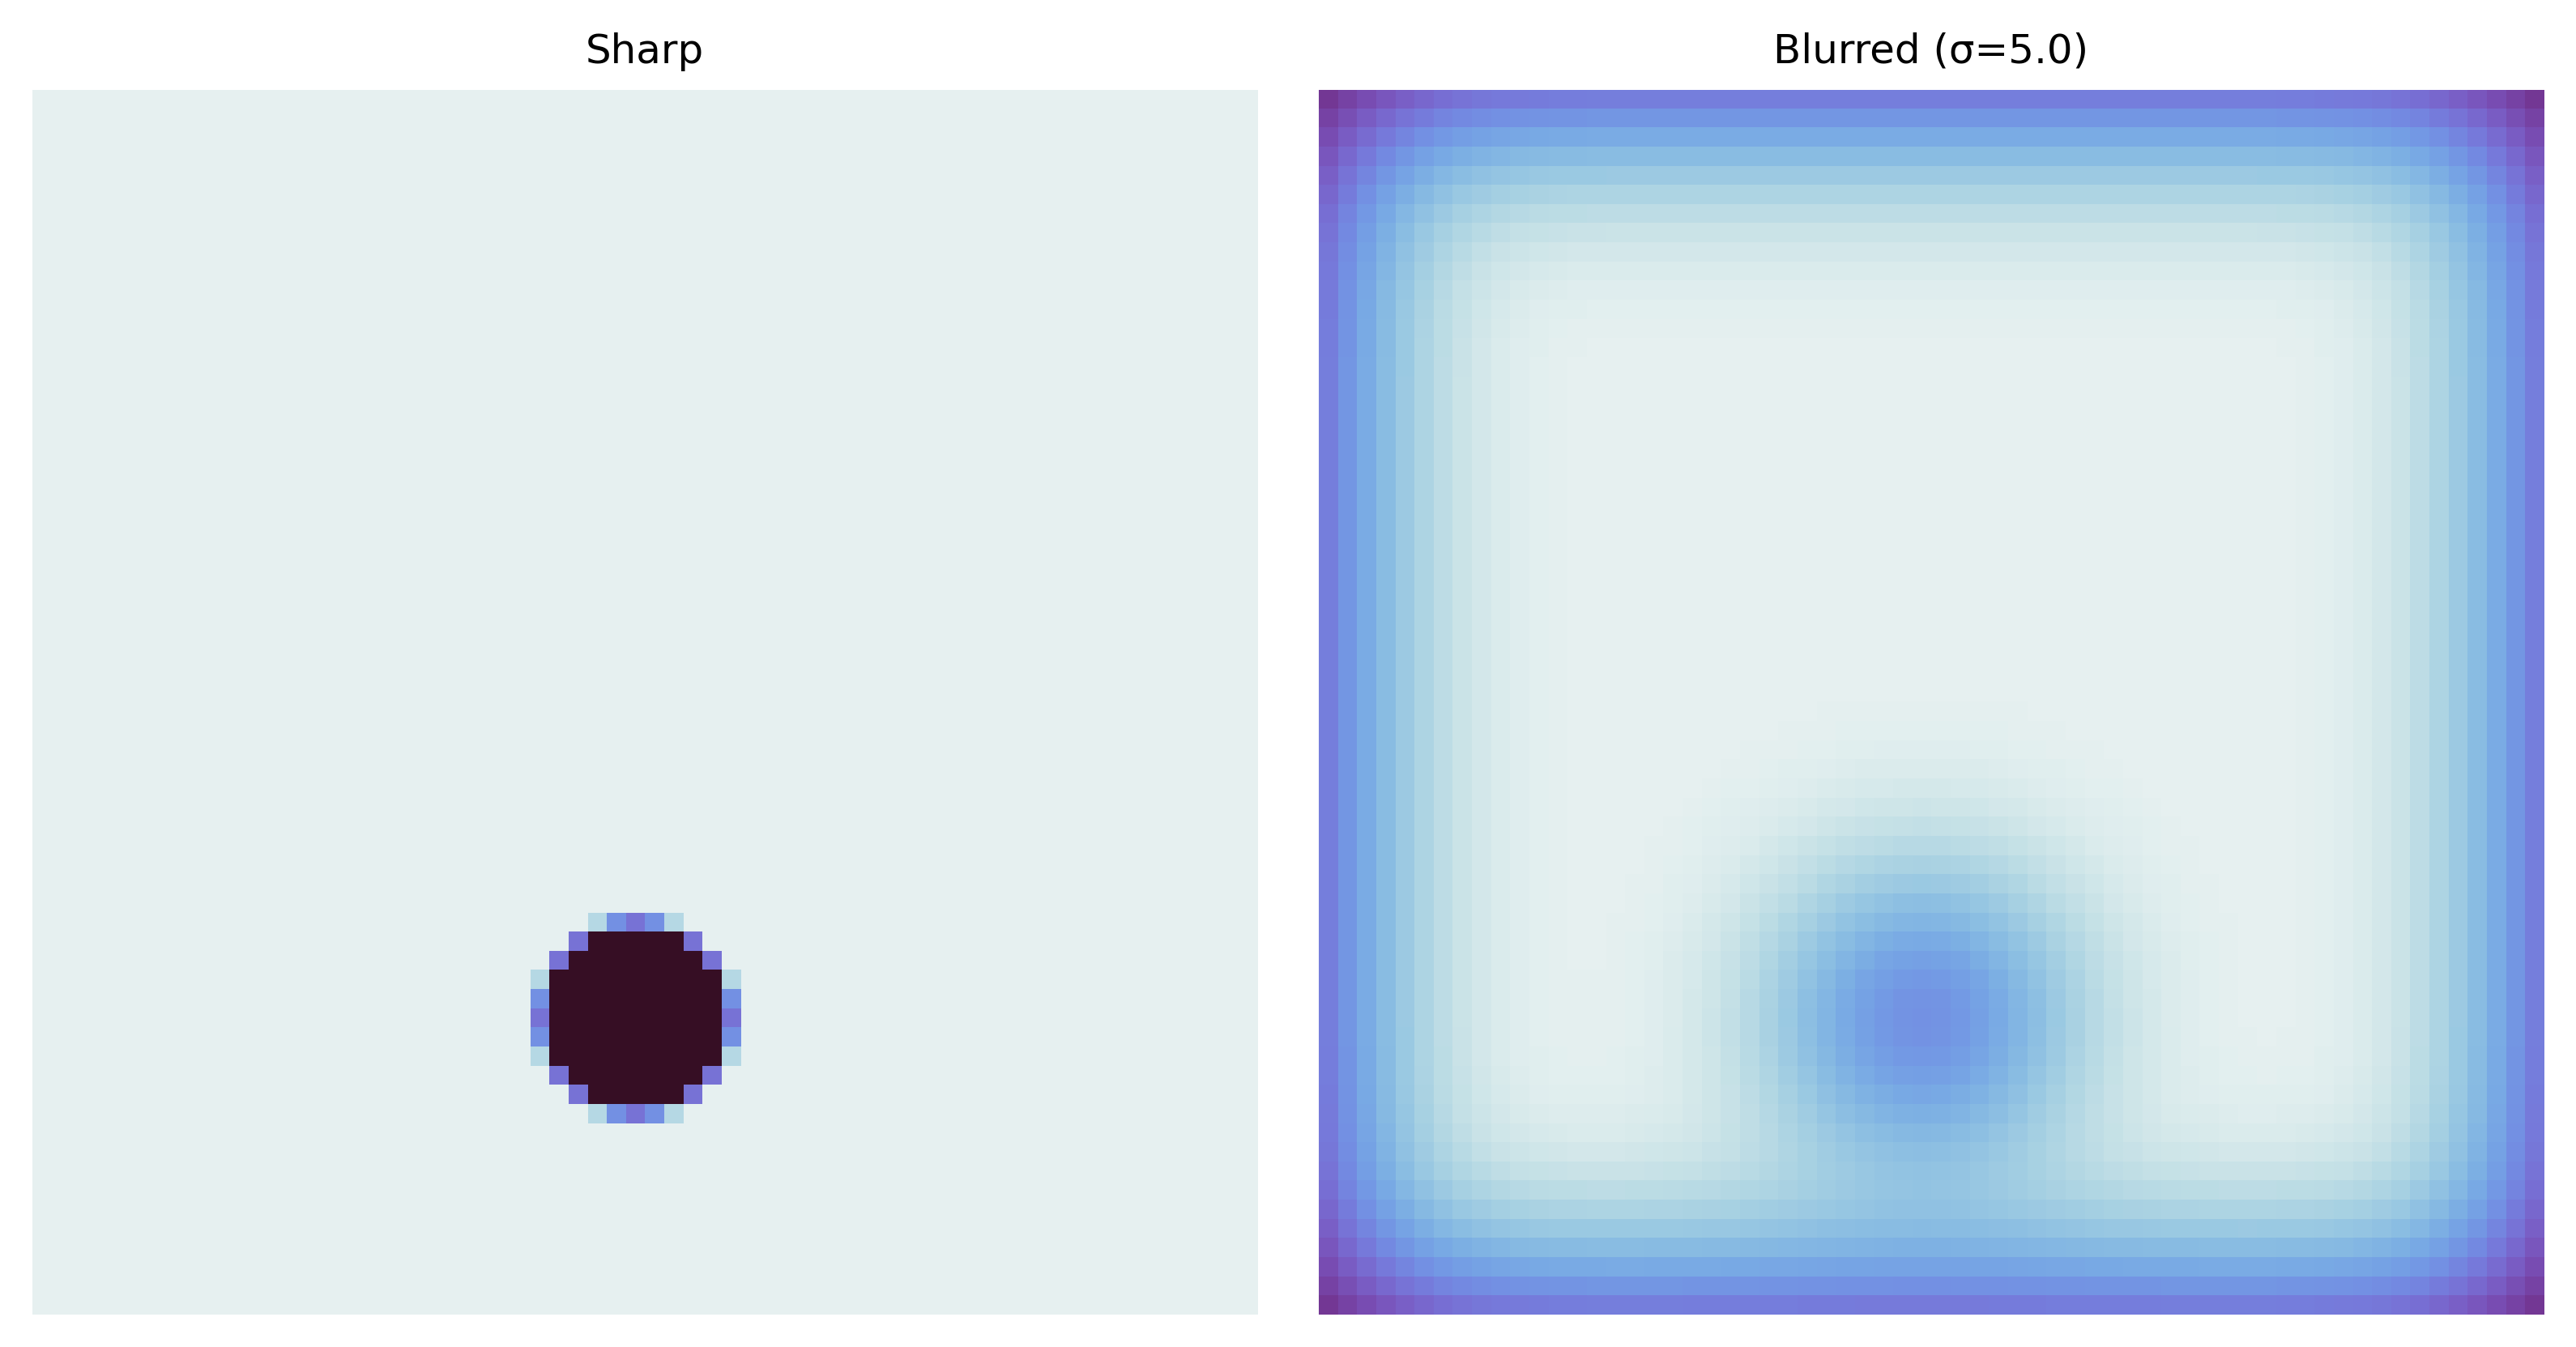

In [31]:
BLUR_SIGMA = 5.0   

def make_blur(sigma: float, device):
    ks = int(6 * sigma + 1)
    ks = ks if ks % 2 == 1 else ks + 1
    half = ks // 2
    coords = torch.arange(ks, dtype=torch.float32) - half
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).to(device)

    conv_x = torch.nn.Conv2d(1, 1, kernel_size=(1, ks), padding=(0, half), bias=False).to(device)
    conv_y = torch.nn.Conv2d(1, 1, kernel_size=(ks, 1), padding=(half, 0), bias=False).to(device)
    with torch.no_grad():
        conv_x.weight.copy_(g.view(1, 1, 1, ks))
        conv_y.weight.copy_(g.view(1, 1, ks, 1))
    for p in (*conv_x.parameters(), *conv_y.parameters()):
        p.requires_grad_(False)

    def H(x: torch.Tensor) -> torch.Tensor:
        return conv_y(conv_x(x))
    return H

H = make_blur(BLUR_SIGMA, device)

splits = torch.load("../../data/circles-64-n1.pt", weights_only=True)
sample = splits["test"][0].unsqueeze(0).to(device)
blurred = H(sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), facecolor="white",
                                gridspec_kw={"wspace": 0.05}, dpi=400)
for ax, img, title in [(ax1, sample, "Sharp"), (ax2, blurred, f"Blurred (σ={BLUR_SIGMA})")]:
    ax.imshow(img.squeeze().cpu().numpy(), cmap=cmocean.cm.dense_r, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
plt.show()


$$\mathcal{L} = ||\text{H}(x_0) - y_{\text{obs}}||^2$$

In [32]:
# our objective function
def mse_cost(x, y):
    return (x - y).pow(2).mean()

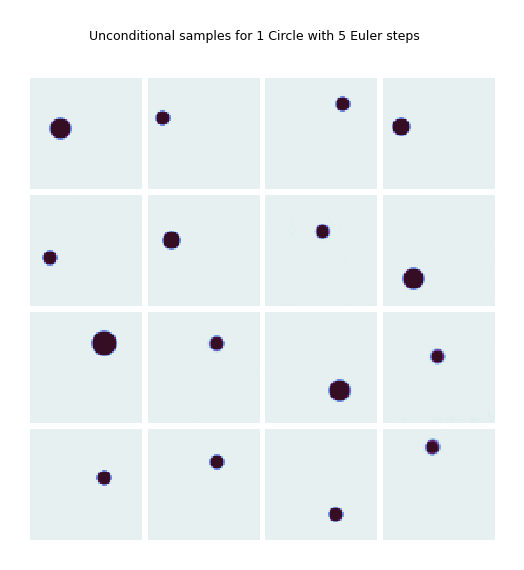

In [33]:
torch.manual_seed(123)

GRID_R, GRID_C = 4, 4

n_grid = GRID_R * GRID_C

with torch.no_grad():
    x0_grid = torch.randn(n_grid, 1, 64, 64, device=device)
    samples_grid = euler_integrate(models[1], x0_grid, n_steps=N_EULER).clamp(0, 1)

fig, axes = plt.subplots(GRID_R, GRID_C,
                         figsize=(GRID_C * 0.5, GRID_R * 0.5),
                         facecolor="white",
                         gridspec_kw={"hspace": 0.05, "wspace": 0.05})
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_grid[i, 0].cpu().numpy(), cmap=cmocean.cm.dense_r,
              vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle(f"Unconditional samples for 1 Circle with {N_EULER} Euler steps",
             fontsize=3, y=0.96)
plt.show()


## D-Flow Optimisation (LBFGS)

In [34]:
import time

torch.manual_seed(123)
results = {}

# ── n=1 hyperparameters ──────────────────────────────────────────────────────
N1_EULER_OPT  = N_EULER
N1_EULER_REND = N_EULER
N1_LR             = 1.0
N1_MAX_ITER       = 20
N1_HISTORY_SIZE   = 25
N1_STEPS          = 10
N1_STOP_LOSS      = 1e-8
LOG_EVERY         = 10
TEST_IDX          = 0

LOSS_SCALE = 1 * 1 * 64 * 64

model = models[1]

test_set = torch.load("../../data/circles-64-n1.pt", weights_only=True)["test"]
y_gt = test_set[TEST_IDX].unsqueeze(0).to(device)
with torch.no_grad():
    y_obs = H(y_gt)

x0 = torch.randn(1, 1, 64, 64, device=device, requires_grad=True)
optimizer = torch.optim.LBFGS(
    [x0], lr=N1_LR, max_iter=N1_MAX_ITER, history_size=N1_HISTORY_SIZE,
    line_search_fn=None, tolerance_grad=1e-12, tolerance_change=1e-16,
)

best_loss       = float("inf")
best_x0         = x0.detach().clone()
best_step       = -1
current_step    = 0                # ← new: visible to closure
last_grad_norm  = 0.0
last_loss       = float("inf")

loss_history, best_loss_history, grad_history = [], [], []

def closure():
    global last_grad_norm, last_loss, best_loss, best_x0, best_step
    optimizer.zero_grad()
    y_pred = euler_integrate(model, x0, n_steps=N1_EULER_OPT)
    diff = H(y_pred) - y_obs
    loss_scaled = diff.pow(2).sum()
    loss_scaled.backward()
    last_grad_norm = x0.grad.norm().item() if x0.grad is not None else 0.0
    last_loss = loss_scaled.item() / LOSS_SCALE
    if last_loss < best_loss:
        best_loss = last_loss
        best_x0   = x0.detach().clone()
        best_step = current_step   # ← new: record the outer step
    return loss_scaled

print("n=1:")
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_start = time.perf_counter()
for step in range(N1_STEPS):
    current_step = step            # ← new
    optimizer.step(closure)

    # (removed the duplicate best-tracking block — closure handles it)

    loss_history.append(last_loss)
    best_loss_history.append(best_loss)
    grad_history.append(last_grad_norm)

    if step % LOG_EVERY == 0:
        elapsed = time.perf_counter() - t_start
        print(f"  [step {step:6d}] loss={last_loss:.6e}  best={best_loss:.6e}  "
              f"|grad|={last_grad_norm:.3e}  lr={N1_LR:.3e}  elapsed={elapsed:7.2f}s")

    if last_loss < N1_STOP_LOSS:
        print(f"  [step {step:6d}] converged — loss={last_loss:.6e}")
        break

if torch.cuda.is_available():
    torch.cuda.synchronize()
total_time = time.perf_counter() - t_start
print(f"  best loss={best_loss:.6e} at step {best_step}")
print(f"  total elapsed: {total_time:.2f}s ({total_time/60:.2f} min)")

with torch.no_grad():
    y_pred_raw = euler_integrate(model, best_x0, n_steps=N1_EULER_REND)
    y_hat      = y_pred_raw.clamp(0, 1)
    Hy_hat_raw = H(y_pred_raw)
    meas_resid_raw = Hy_hat_raw - y_obs
    meas_mse_raw   = meas_resid_raw.pow(2).mean().item()
 
results[1] = {
    "y_gt": y_gt.cpu(), "y_obs": y_obs.cpu(),
    "y_hat": y_hat.cpu(), "err": (y_hat - y_gt).cpu(),
    "y_pred_raw":     y_pred_raw.cpu(),
    "Hy_hat_raw":     Hy_hat_raw.cpu(),
    "meas_resid_raw": meas_resid_raw.cpu(),
    "meas_mse_raw":   meas_mse_raw,
    "best_loss": best_loss, "best_step": best_step,
    "elapsed_s": total_time,
    "loss_history": loss_history,
    "best_loss_history": best_loss_history,
    "grad_history": grad_history,
}

n=1:
  [step      0] loss=1.484964e-02  best=1.093276e-02  |grad|=6.560e-01  lr=1.000e+00  elapsed=   2.78s
  best loss=8.988957e-07 at step 9
  total elapsed: 46.85s (0.78 min)


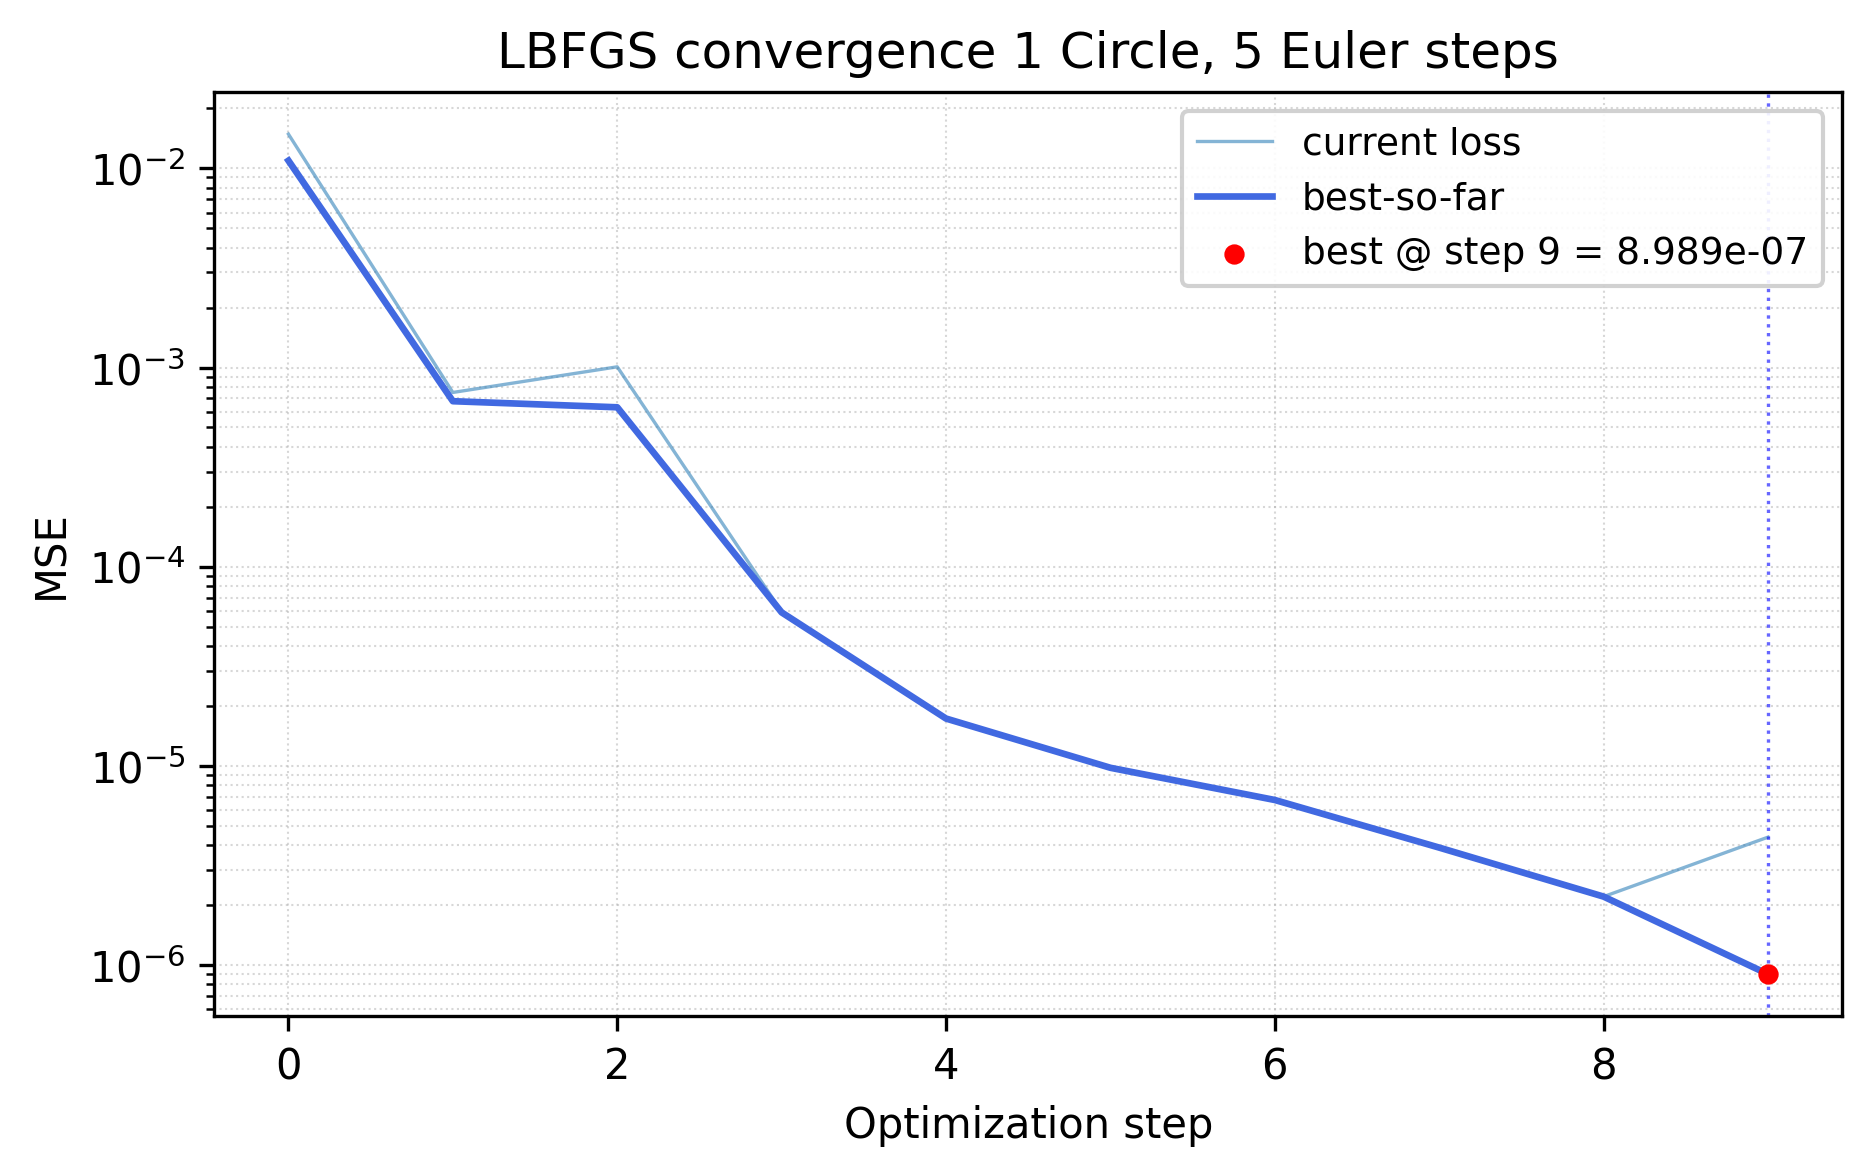

In [35]:
import numpy as np

res = results[1]
steps = np.arange(len(res["loss_history"]))
loss  = np.asarray(res["loss_history"])
best  = np.asarray(res["best_loss_history"])

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white", dpi=300)
ax.plot(steps, loss, lw=0.8, alpha=0.55, label="current loss")
ax.plot(steps, best, lw=1.6, color="royalblue",  label="best-so-far")


ax.axvline(res["best_step"], color="blue", ls=":", lw=0.8, alpha=0.6)
ax.scatter([res["best_step"]], [res["best_loss"]],
           color="red", s=15, zorder=5,
           label=f"best @ step {res['best_step']} = {res['best_loss']:.3e}")

ax.set_yscale("log")
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"MSE")
ax.set_title(f"LBFGS convergence 1 Circle, {N_EULER} Euler steps")
ax.grid(True, which="both", ls=":", lw=0.5, alpha=0.5)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
plt.show()

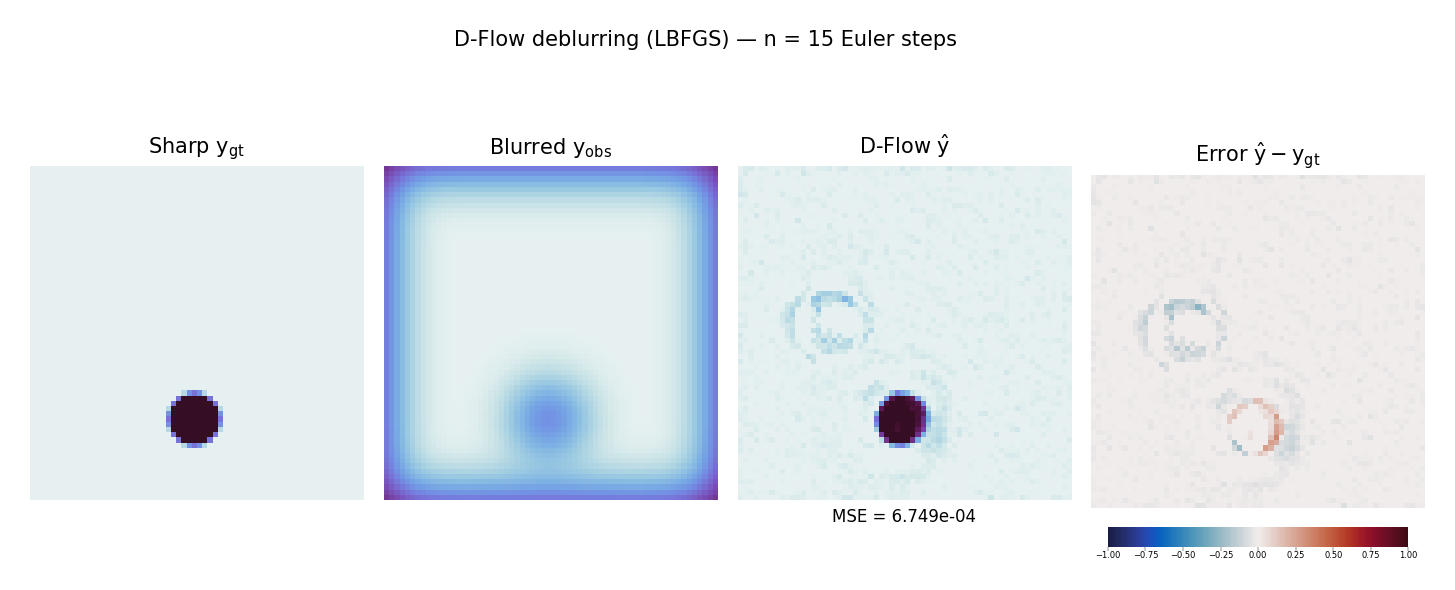

In [36]:
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["mathtext.default"] = "regular"

col_labels = [r"Sharp $y_{\mathrm{gt}}$", r"Blurred $y_{\mathrm{obs}}$",
              r"D-Flow $\hat{y}$", r"Error $\hat{y} - y_{\mathrm{gt}}$"]
ncols = len(col_labels)

fig, axes = plt.subplots(1, ncols, figsize=(6, 2), facecolor="white",
                         gridspec_kw={"wspace": 0.06}, dpi=300)

n = 1
res = results[n]
elim = max(res["err"].abs().max().item(), 1e-8)
mse  = res["err"].pow(2).mean().item()

panels = [
    (res["y_gt"],  cmocean.cm.dense_r,  0,  1),
    (res["y_obs"], cmocean.cm.dense_r,  0,  1),
    (res["y_hat"], cmocean.cm.dense_r,  0,  1),
    (res["err"],   cmocean.cm.balance, -1,  1),
]

ims = []
for col, (img, cmap, vmin, vmax) in enumerate(panels):
    ax = axes[col]
    im = ax.imshow(img.squeeze().numpy(), cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(col_labels[col], fontsize=5, pad=3)
    ims.append(im)

axes[2].set_xlabel(f"MSE = {mse:.3e}", fontsize=4, labelpad=2)

# Horizontal colorbar under the error panel only
cbar = fig.colorbar(
    ims[-1], ax=axes[-1],
    orientation="horizontal",
    fraction=0.08, pad=0.04, aspect=15, shrink=0.9,
)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=2, length=1.0, width=0.1, pad=0)

fig.suptitle(rf"D-Flow deblurring (LBFGS) — n = {n}"
             rf"{N_EULER} Euler steps", fontsize=5, y=1.0)
plt.show()

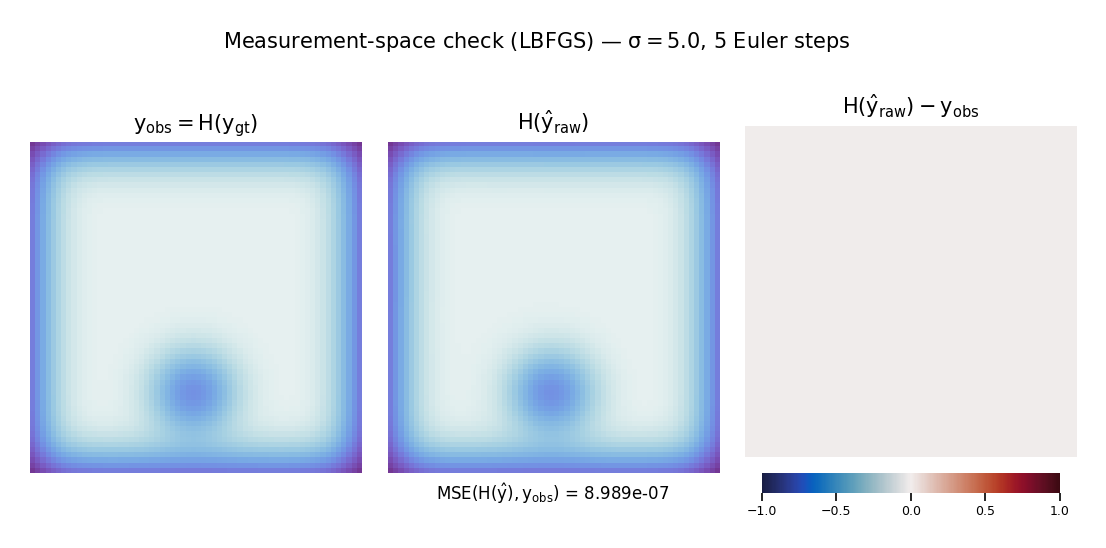

In [37]:
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["mathtext.default"] = "regular"

res = results[1]
mr     = res["meas_resid_raw"]
mr_lim = max(mr.abs().max().item(), 1e-12)

panels = [
    (res["y_obs"],      cmocean.cm.dense_r,  0,  1,            r"$y_{\mathrm{obs}} = H(y_{\mathrm{gt}})$"),
    (res["Hy_hat_raw"], cmocean.cm.dense_r,  0,  1,            r"$H(\hat{y}_{\mathrm{raw}})$"),
    (mr,                cmocean.cm.balance, -1, 1,   r"$H(\hat{y}_{\mathrm{raw}}) - y_{\mathrm{obs}}$"),
]

fig, axes = plt.subplots(1, 3, figsize=(4.5, 1.7), facecolor="white",
                         gridspec_kw={"wspace": 0.08}, dpi=300)

ims = []
for ax, (img, cmap, vmin, vmax, title) in zip(axes, panels):
    im = ax.imshow(img.squeeze().numpy(), cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(title, fontsize=5, pad=3)
    ims.append(im)

axes[1].set_xlabel(rf"MSE$(H(\hat{{y}}), y_{{\mathrm{{obs}}}})$ = {res['meas_mse_raw']:.3e}",
                   fontsize=4, labelpad=2)

cbar = fig.colorbar(ims[2], ax=axes[2], orientation="horizontal",
                    fraction=0.08, pad=0.04, aspect=15, shrink=0.9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=3, length=2.0, width=0.4, pad=1)
cbar.formatter.set_powerlimits((-2, 2))
cbar.update_ticks()

fig.suptitle(rf"Measurement-space check (LBFGS) — $\sigma = {BLUR_SIGMA}$, "
             rf"{N_EULER} Euler steps", fontsize=5, y=1.04)
plt.show()
